# SIOC 251 – Homework 1 Notebook

## Monte Carlo Model of Solar Radiation in an Absorbing Atmosphere  

**Name:** Amanda Mallinckrodt  
**Date:** 04/20/26

## Problem Statement

Using Beer's law to create a parallel plane model, determining extinction events and transmittance of photons to the surface in an absorbing atmosphere with respect to changing solar zenith angle and total optical depth

### Atmosphere Parameters
The atmosphere is modeled as a homogeneous, dry atmosphere with a depth defined by the scale height ($H$):

* **Scale Height ($H$):**
    $$H = \frac{kT}{mg}$$
* **Atmospheric Depth ($Z_{atm}$):**
    $Z_{atm} = 8.5 \text{ km}$
* **Dry Adiabatic Lapse Rate:**
    $-\frac{dT}{dz}$


## Step 1: Creating the Monte Carlo Model 

The initial model was set up to accept user inputs for the number of incident photons (N_INCIDENT), the total optical depth of the atmosphere (TAU_STAR), the solar zenith angle of the incident photons (SZA_DEG), and the depth of the homogeneous atmosphere (Z_ATM). The simulation first defines: 

* **Cosine of Solar Zenith Angle ($\mu$):**
    $$\mu = \cos \theta $$

* **Maximum Pathlength ($L_{max}$):**
    $$L_{max} = \frac{Z_{atm}}{\mu} $$


Then the simulation loop generates a random number between 0 and 1 for N_INCIDENT photons and finds the corresponding tau_z from the probability functions below.

* **Probability of reaching the surface:**
    $$P(\tau) = e^{-\tau}$$
* **Cumulative Distribution Function (CDF):**
    $$\text{CDF}(\tau) = 1 - e^{-\tau}$$
* **Sampled Optical Depth ($\tau$):**
    Given a random value $\zeta$ (uniformly distributed between 0 and 1):
    $$\tau = -\ln(1 - \zeta)$$

The calculated tau_z is compared to TAU_STAR to determine if the photon is extinguished (tau_z < tau_star) or reaches the surface (tau_z ≥ tau_star). If the photon is extinguished, the extinction pathlength is calculated. 

 $$L_{ext} = L_{max}  \frac{\tau_{(z)}}{\tau^*} $$



In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- USER INPUTS ---
N_INCIDENT = 100000 
TAU_STAR = 3
SZA_DEG = 60
Z_ATM = 8500  # 8.5 km

def run_simulation():
    # Setup geometry
    mu = np.cos(np.radians(SZA_DEG))
    L_max = Z_ATM / mu
    
    ext_paths = []
    surf_count = 0
    
    # Run Monte Carlo loop
    for _ in range(N_INCIDENT):
        zeta = np.random.rand()
        tau_z = -np.log(1 - zeta)
        
        if tau_z >= TAU_STAR:
            surf_count += 1
        else:
            # Formula: L = (Z_atm / mu) * (tau_z / tau_star)
            L_ext = L_max * (tau_z / TAU_STAR)
            ext_paths.append(L_ext)

## Statistics and Plotting

The relevant statistics are calculated and output 

* total extinction count 
* extinction count as % of the incident photons 
* surface count as a % of the incident photons 
* theoretical surface transmission % 

The simulation results are shown as a histogram of $L_{ext}$ for all extinguished incident photons and the count of photons that reached the surface, normalized to the % of total photons. 

------------------------------
MONTE CARLO RESULTS (N=100,000)
------------------------------
Reached Surface:      4,878 (4.88%)
Extinguished in Atm:  95,122 (95.12%)
Theoretical e^-tau:   4.98%
------------------------------


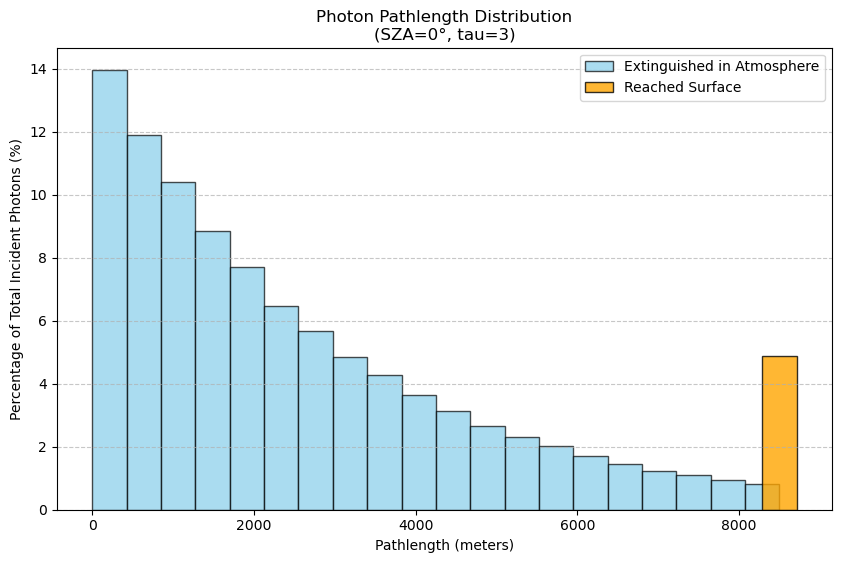

Figure successfully saved to: figures/mcrt_tau3_sza0.png


<Figure size 640x480 with 0 Axes>

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- USER INPUTS ---
N_INCIDENT = 100000 
TAU_STAR = 3
SZA_DEG = 0
Z_ATM = 8500  # 8.5 km

def run_simulation():
    # Setup geometry
    mu = np.cos(np.radians(SZA_DEG))
    L_max = Z_ATM / mu
    
    ext_paths = []
    surf_count = 0
    
    # Run Monte Carlo loop
    for _ in range(N_INCIDENT):
        zeta = np.random.rand()
        tau_z = -np.log(1 - zeta)
        
        if tau_z >= TAU_STAR:
            surf_count += 1
        else:
            # Formula: L = (Z_atm / mu) * (tau_z / tau_star)
            L_ext = L_max * (tau_z / TAU_STAR)
            ext_paths.append(L_ext)
    
    # Calculate statistics
    ext_count = len(ext_paths)
    surf_pct = (surf_count / N_INCIDENT) * 100
    ext_pct = (ext_count / N_INCIDENT) * 100
    theoretical_pct = np.exp(-TAU_STAR) * 100

    # --- PRINT STATISTICS ---
    print("-" * 30)
    print(f"MONTE CARLO RESULTS (N={N_INCIDENT:,})")
    print("-" * 30)
    print(f"Reached Surface:      {surf_count:,} ({surf_pct:.2f}%)")
    print(f"Extinguished in Atm:  {ext_count:,} ({ext_pct:.2f}%)")
    print(f"Theoretical e^-tau:   {theoretical_pct:.2f}%")
    print("-" * 30)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    
    # Histogram for atmospheric extinctions (blue)
    weights = np.ones_like(ext_paths) * 100.0 / N_INCIDENT
    plt.hist(ext_paths, bins=20, weights=weights, color='skyblue', 
             edgecolor='black', alpha=0.7, label='Extinguished in Atmosphere')
    
    # Bar for surface reaches (orange)
    plt.bar(L_max, surf_pct, width=L_max/20, color='orange', 
            edgecolor='black', alpha=0.8, label='Reached Surface')
    
    plt.title(f'Photon Pathlength Distribution\n(SZA={SZA_DEG}°, tau={TAU_STAR})')
    plt.xlabel('Pathlength (meters)')
    plt.ylabel('Percentage of Total Incident Photons (%)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Execute
run_simulation()

import os

folder_name = "figures"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

file_path = os.path.join(folder_name, f"mcrt_tau{TAU_STAR}_sza{SZA_DEG}.png")

plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"Figure successfully saved to: {file_path}")

# Model Validation Tests
---------
### 1) When $\tau^*$ is equal to zero
### 2) When Solar Zenith Angle $\cos{theta}$ is equal to 90
### 3) $\Delta_{theoretical-simulation}$ for surface transmission decreases as N incident photons increases 
---------

### Test 1
* Changing $\tau^*$ to 0 → all photons should pass through the atmosphere

Result: Passed
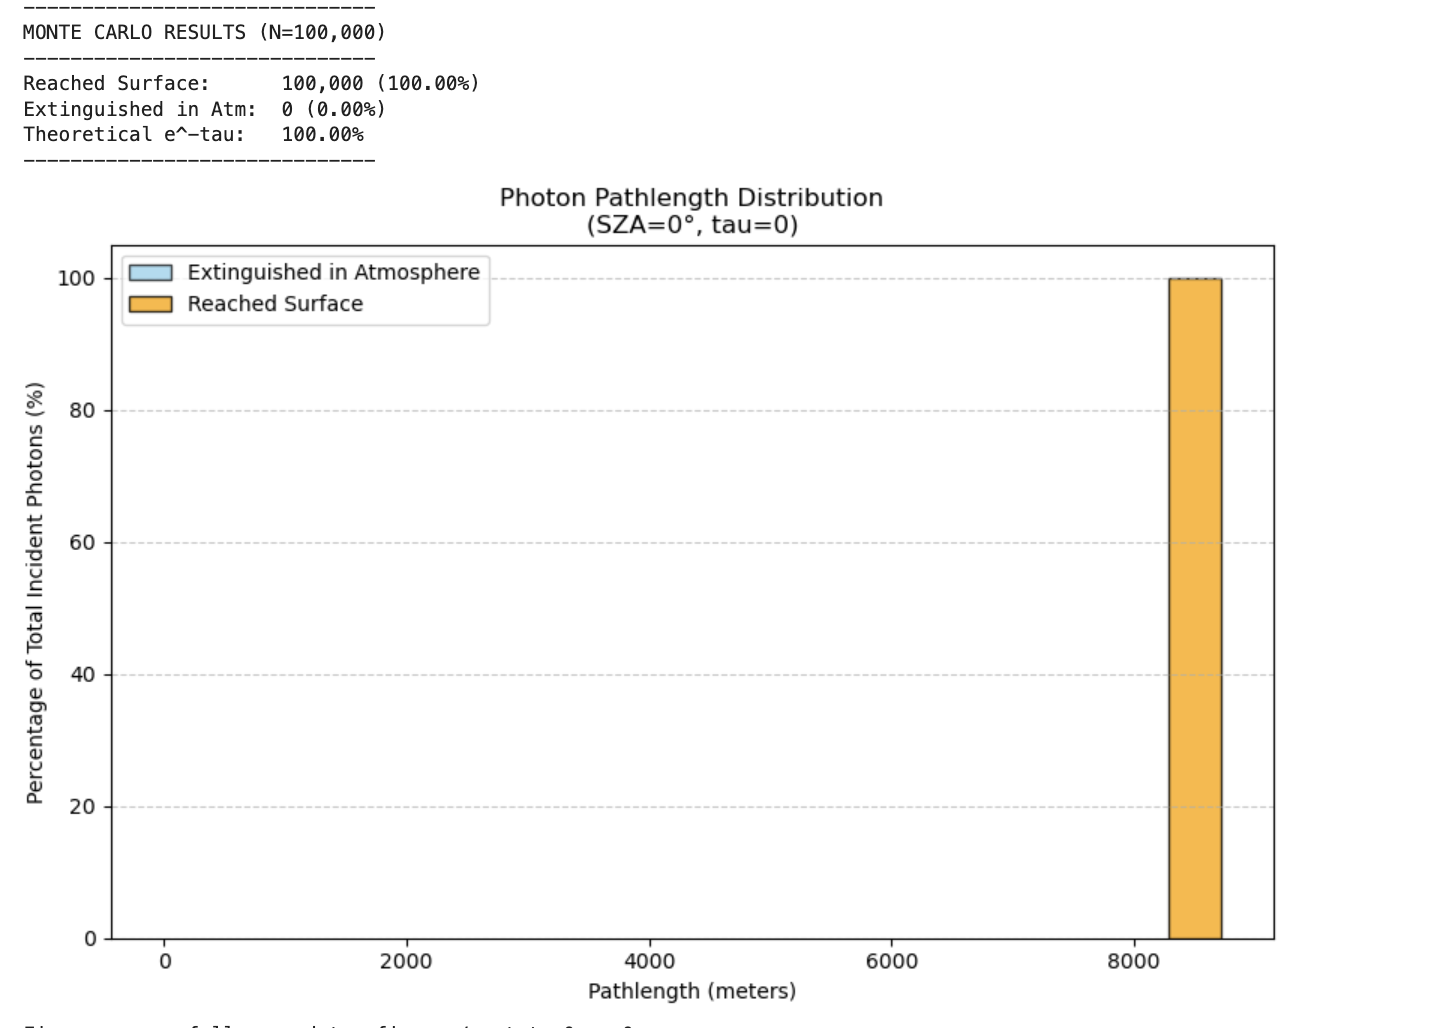

----------
### Test 2
* Changing the SZA to 90 → shouldn't work since the incident photon trajectory never reaches the surface, but the simulation ran... this led me to realize all SZA inputs had the same output for a constant $\tau^* $ value, which deviates from expectation

Result: Failed 
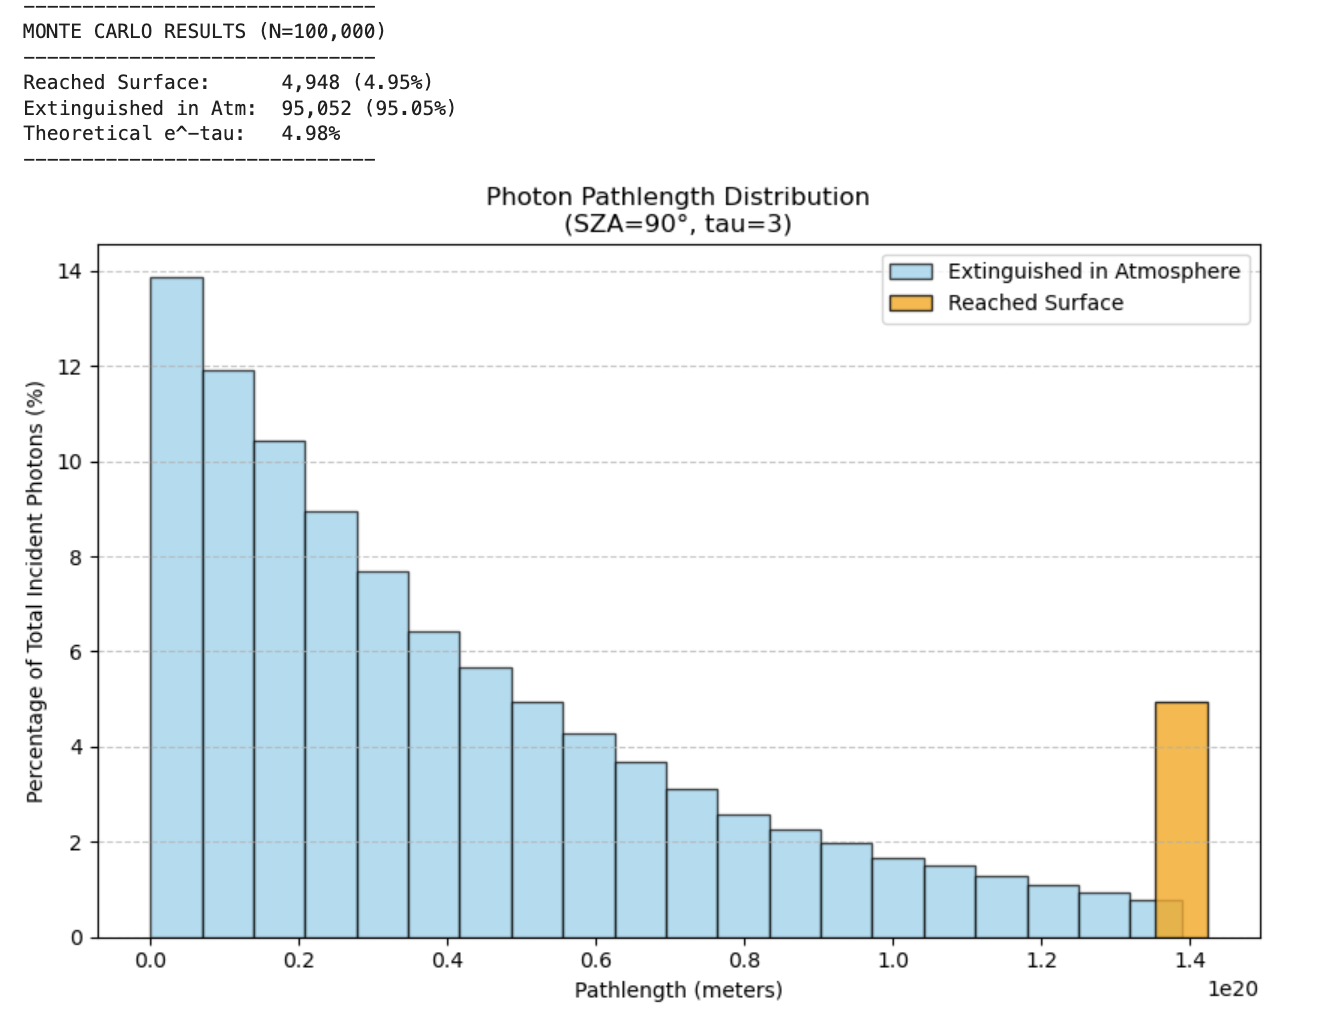

* Why it failed: The path length would be longer at a nonzero zenith angle, since it's not directly overhead, leading to a greater probability of extension events. After looking back at my model, I noticed that because I was only comparing $\tau_{z}$ and $\tau^*$ to determine whether the photons reached the surface, I was not accounting for the actual photon path length at any zenith angle other than 0.

* To address this, I implemented a slant-path $\frac{\tau^*}{\mu}$  in the revised model below to adjust $ \tau^*$ based on the zenith angle. 


MONTE CARLO RESULTS (N=10,000)
--- Results for SZA 0 ---
Extinguished in Atm:  9,526 (95.26%)
Surface Hits: 474 (4.74%)
Theoretical:  4.98%


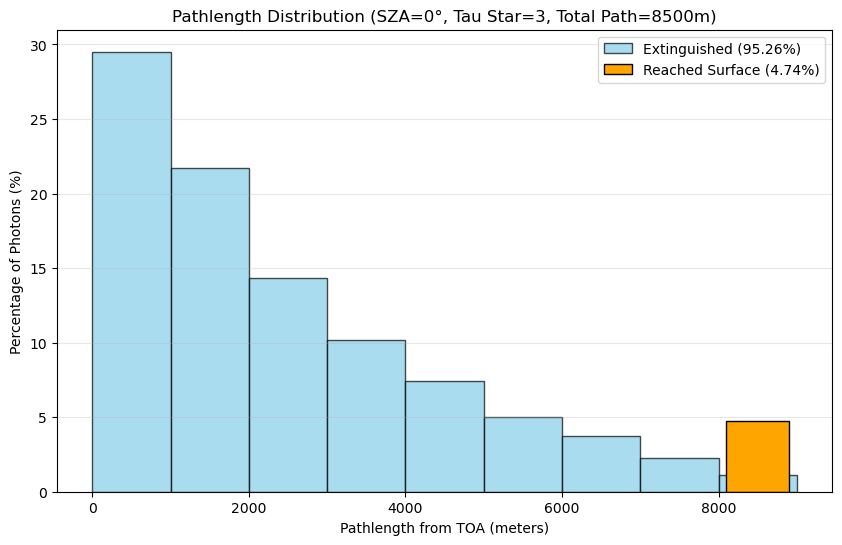

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parameters ---
N_INCIDENT = 10000 
TAU_STAR = 3
SZA_DEG = 0    
Z_ATM = 8500 
BIN_SIZE = 1000 

def run_simulation():
    # 1. Set up Slant path
    mu = np.cos(np.radians(SZA_DEG))
    mu = max(mu, 0.0001) 
    
    tau_slant_path = TAU_STAR / mu 
    L_total = Z_ATM / mu 

    surf_paths = [] 
    ext_paths = []

    #  Monte Carlo Loop
    for _ in range(N_INCIDENT):
        zeta = np.random.rand()
        tau_sampled = -np.log(1 - zeta)
        
        if tau_sampled >= tau_slant_path:
            # Reaches surface diagonal end
            surf_paths.append(L_total)
        else:
            # Extinction along the diagonal
            # L = (Zatm / mu) * (tau_sampled / tau_star)
            L_ext = (Z_ATM / mu) * (tau_sampled / TAU_STAR)
            ext_paths.append(L_ext)

    # 3. Statistics
    surf_count = len(surf_paths)
    ext_count = len(ext_paths)
    ext_pct = (ext_count / N_INCIDENT) * 100
    surf_pct = (surf_count / N_INCIDENT) * 100
    theory_pct = np.exp(-tau_slant_path) * 100
    
    print(f"MONTE CARLO RESULTS (N={N_INCIDENT:,})")
    print(f"--- Results for SZA {SZA_DEG} ---")
    print(f"Extinguished in Atm:  {ext_count:,} ({ext_pct:.2f}%)")
    print(f"Surface Hits: {surf_count:,} ({surf_pct:.2f}%)")
    print(f"Theoretical:  {theory_pct:.2f}%")

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, L_total + BIN_SIZE, BIN_SIZE)
    
    # Histogram of extinction locations
    plt.hist(ext_paths, bins=bins, weights=np.ones_like(ext_paths)*100/N_INCIDENT, 
             color='skyblue', edgecolor='black', alpha=0.7, label=f'Extinguished ({ext_pct:.2f}%)')
    
    # Final Surface Bar
    plt.bar(L_total, surf_pct, width=BIN_SIZE*0.8, color='orange', 
            edgecolor='black', label=f'Reached Surface ({surf_pct:.2f}%)')

    plt.title(f'Pathlength Distribution (SZA={SZA_DEG}°, Tau Star={TAU_STAR}, Total Path={L_total:.0f}m)')
    plt.xlabel('Pathlength from TOA (meters)')
    plt.ylabel('Percentage of Photons (%)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 5. Save to Folder
    folder = "figures"
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    file_path = os.path.join(folder, f"mcrt_sza{SZA_DEG}_tau{TAU_STAR}.png")
    plt.savefig(file_path, dpi=300)
    plt.show()

    

run_simulation()


### Test 2 cont. 

* The revised model correctly accounts for the solar zenith angle in the probability of incident photons reaching the surface

  Result: Passed
  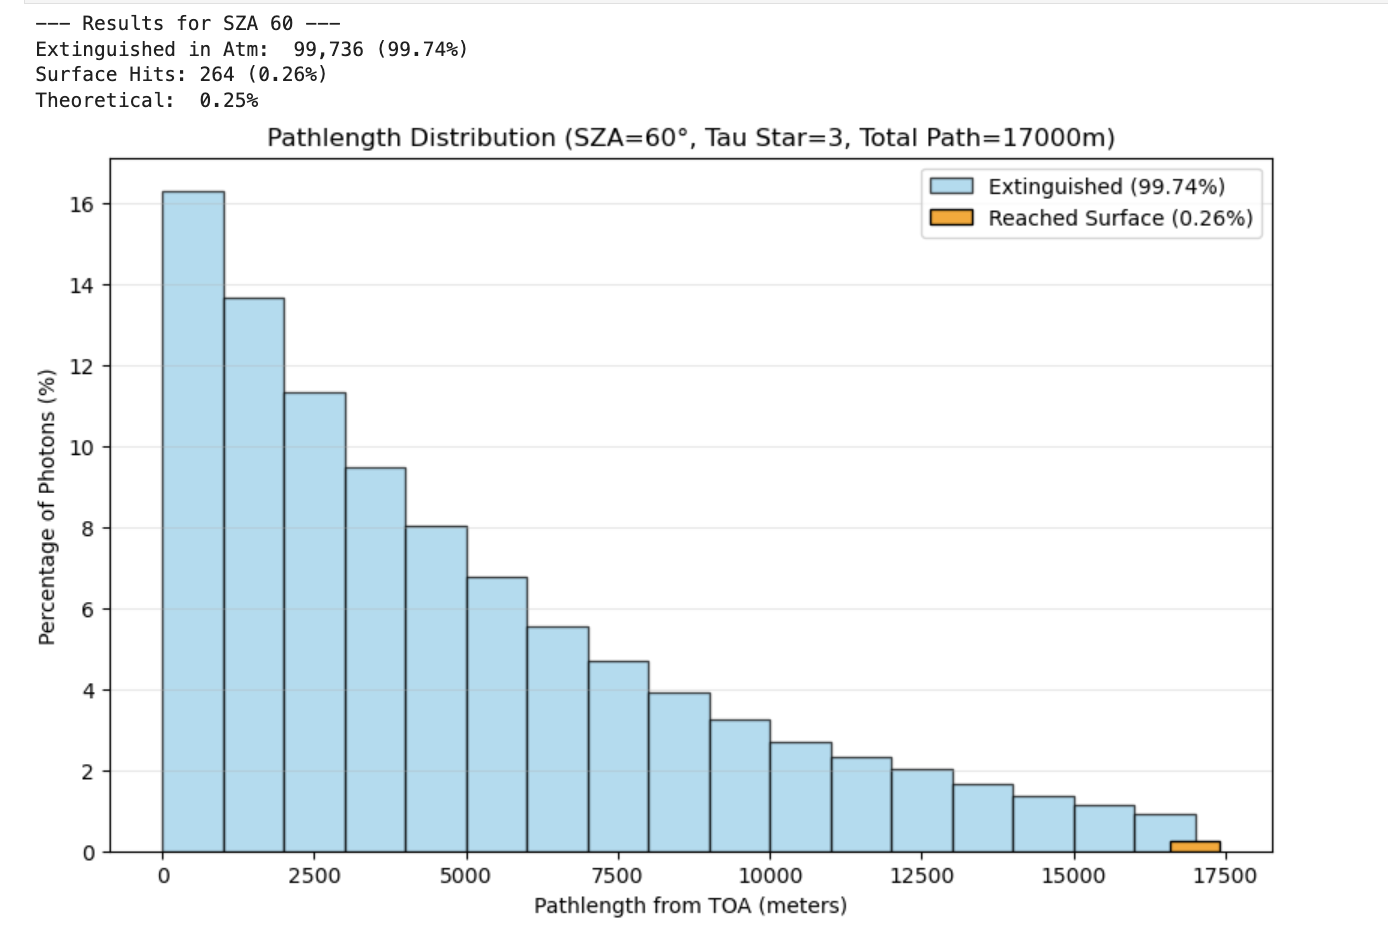

### Test 3 

* Increasing the N incident photons from 10,000 to 100,000 decreases the deviation between the theoretical and simulation output according to the Central Limit Theorem
  * For N=100,000 $\Delta_(theoretical-simulated) $ = 0.02
  * For N=10,000 $\Delta_(theoretical-simulated) $ = 0.14

  Result: Passed

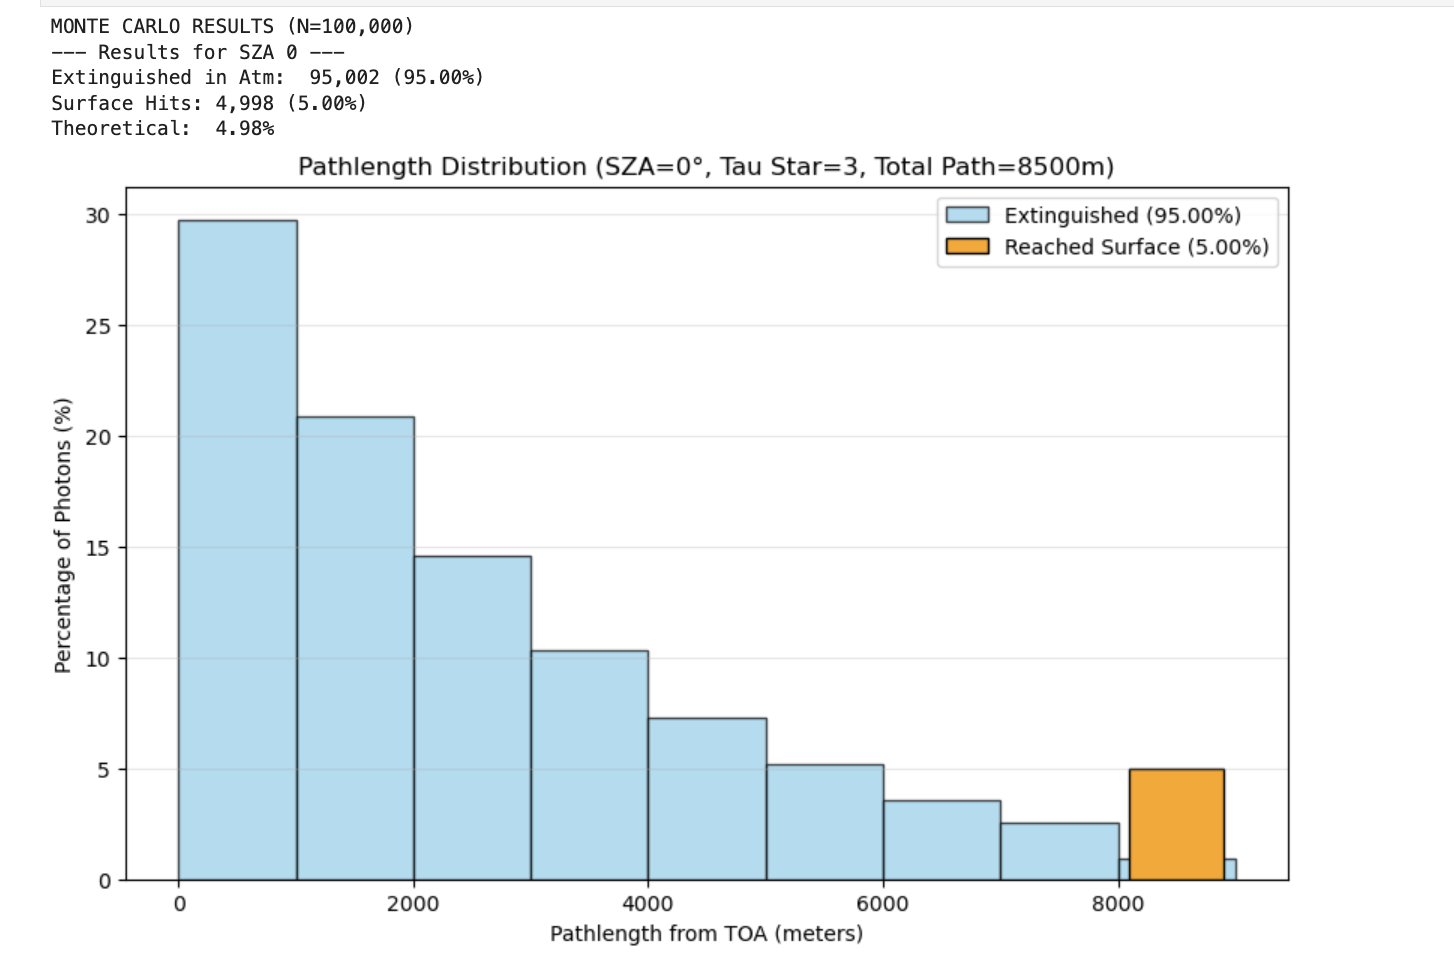
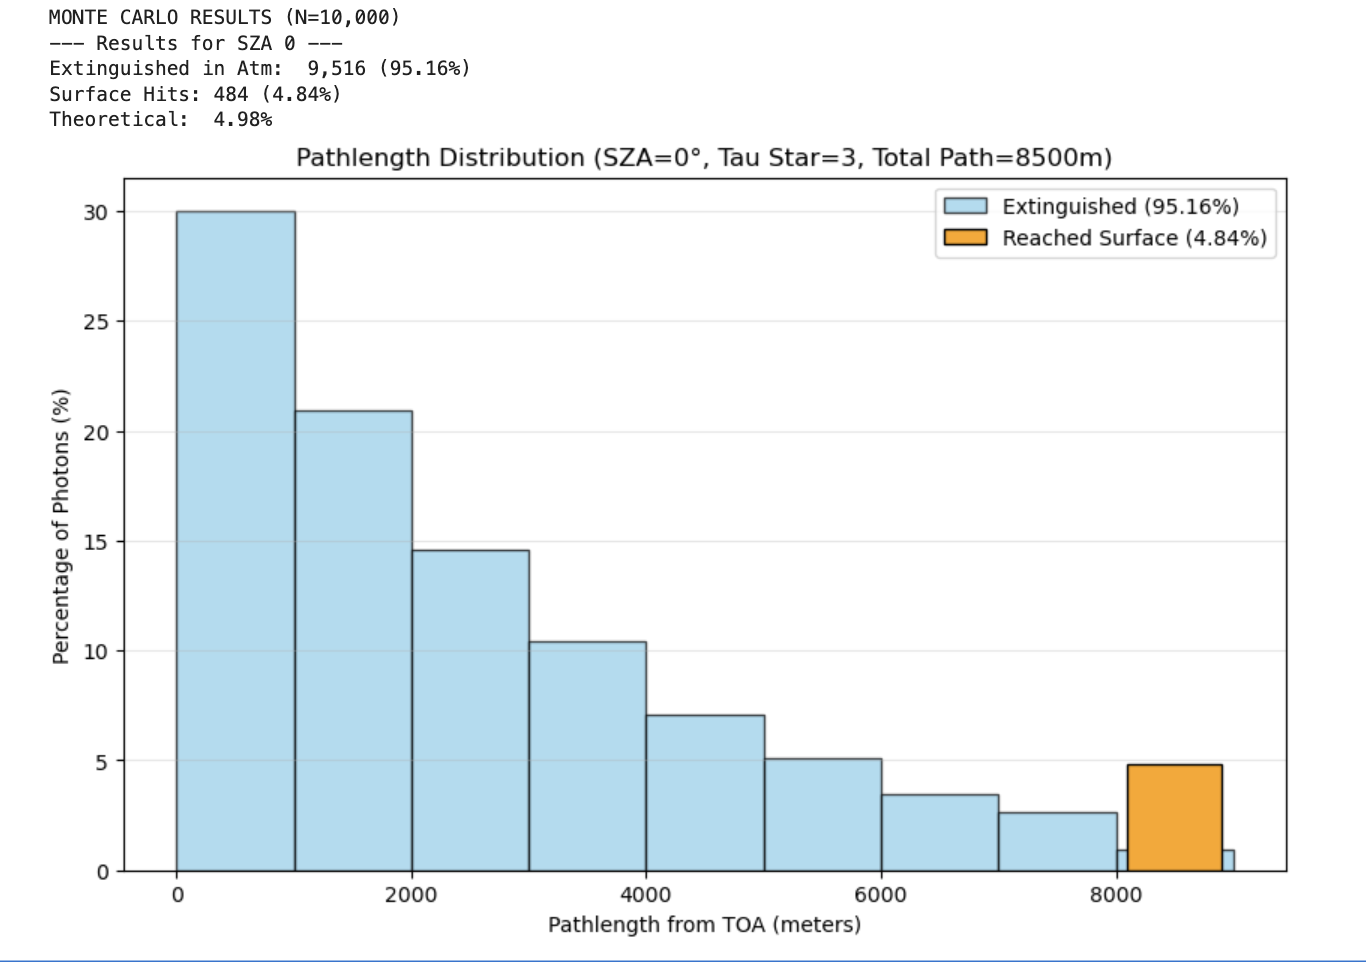

# Part III: 

1. For the sun directly overhead (θ = 0), what is the value of optical depth τ that results in an
e-folding reduction in surface intensity?
	
    e^0 would be 100% of photons reach the surface, so e^1 is a factor of 2.71 (equivalent to e) less photons reaching the surface which is roughly 37% of e^0

So the value of tau resulting in an e-folding reduction is N+1 

2. For τ = 1, what is the surface transmittance t when the solar zenith angle is 60◦?

With SZA 60˚, the surface transmittance is 13.48% according to my model
The theoretical value would be e^1/cos(60) which is about 13.5%

3. Explain why, in a purely absorbing atmosphere, the surface would be dark when the sun
reaches the horizon (assume the sun is a point source).

In a purely absorbing atmosphere, there is no scattering of light that would redirect light towards the surface. In the parallel plane model, 90˚ would be considered the horizon, and in this case, the depth of the atmosphere is infinite because it is parallel to the ground. Therefore, the light will never make contact with the surface

4. For τ = 1, 3, and 10, how does transmittance vary with height in the atmosphere?

For $\tau$ = 1, the distribution of extinction path lengths through the atmosphere is relatively consistent from the TOA to the surface. When $\tau$ = 3, the distribution begins to favor extinction path lengths at higher altitudes, shifting the distribution towards an exponential decay function and reducing transmittance to the surface significantly. At $\tau$ = 10, the exponential decay function is apparent, and 0% of the photons in the simulation are transmitted to the surface. 

   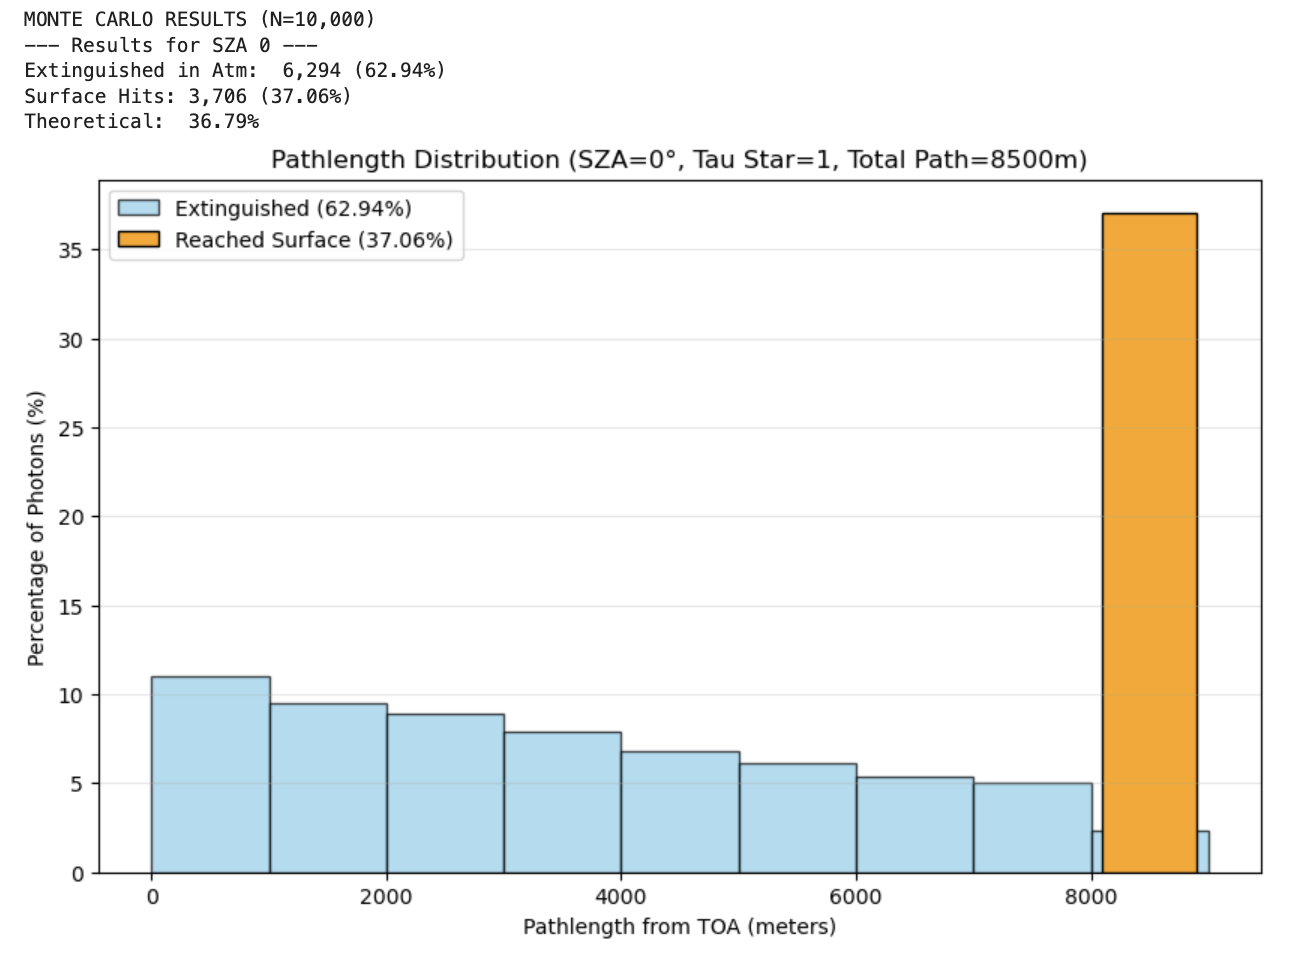
   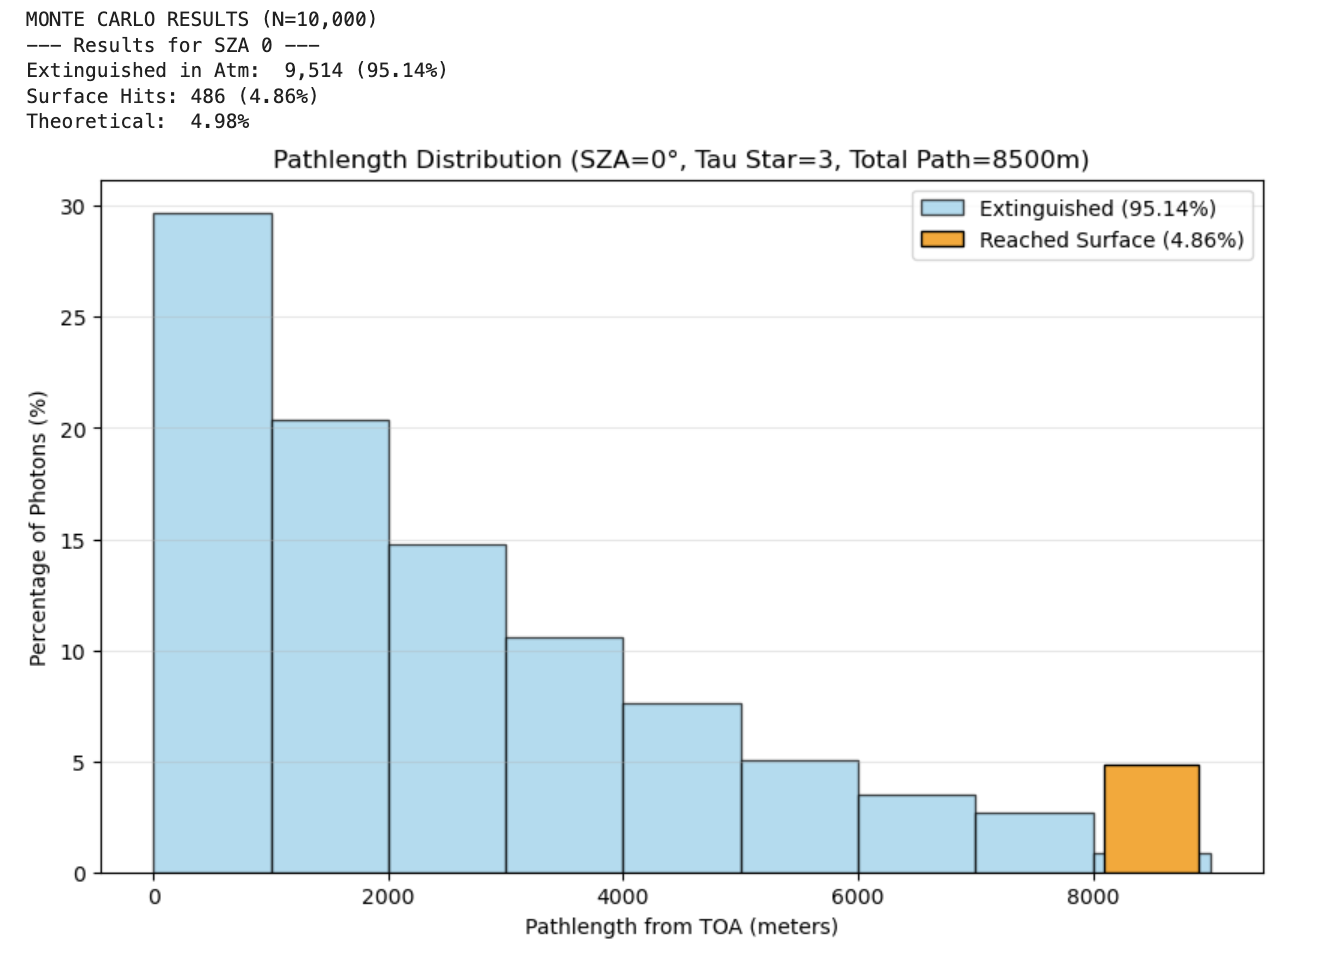
   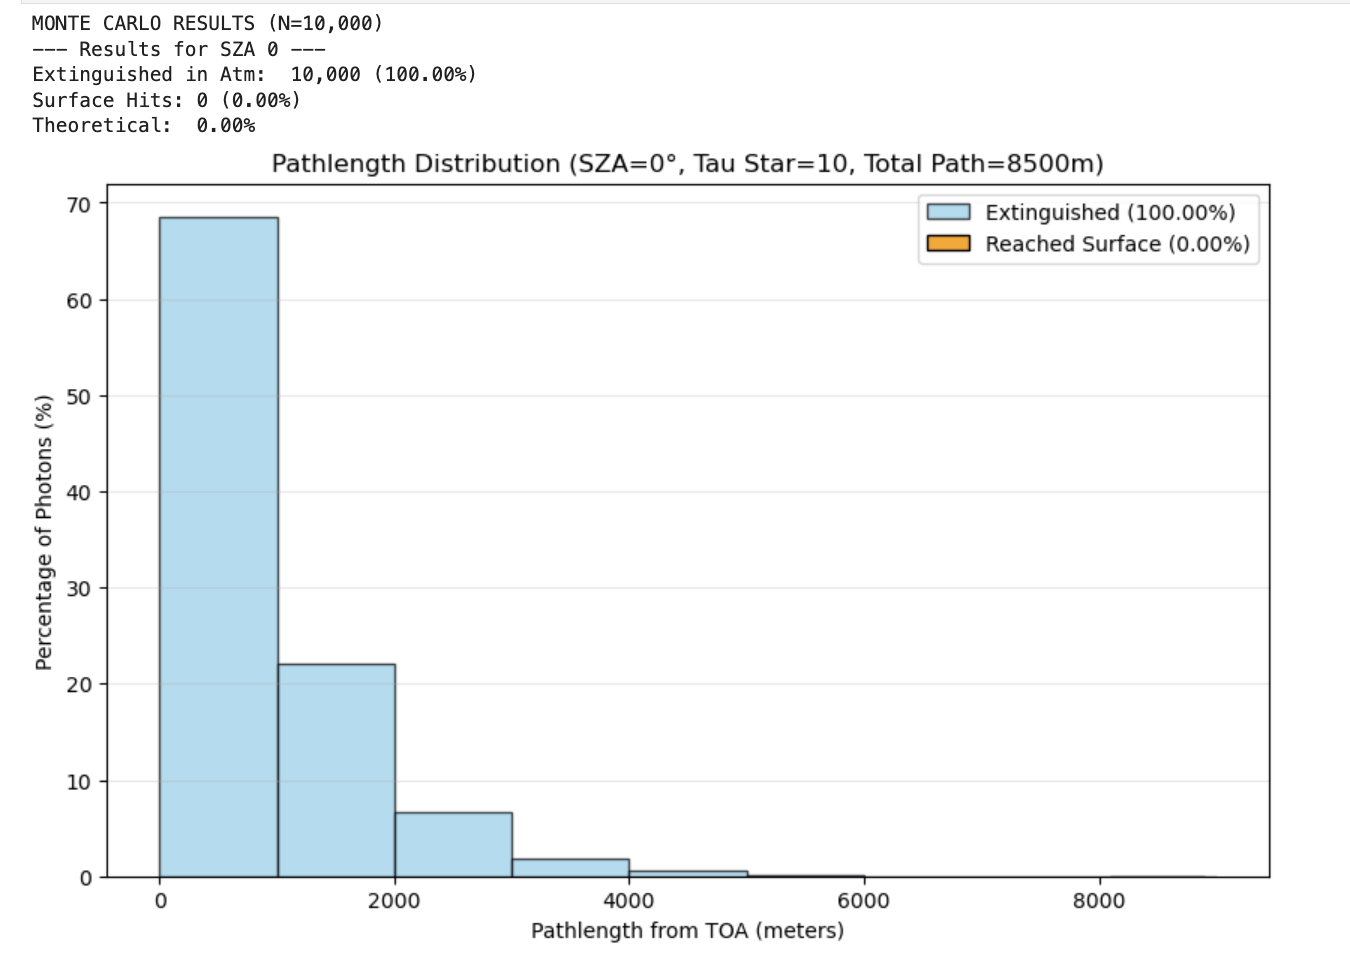


# Part IV: Aeronet Observations 

I picked the Goldstone Station outside of Barstow, California, on September 23rd 2021. The table below shows the hourly averages for aerosol optical depth at 500nm and the corresponding average solar zenith angle

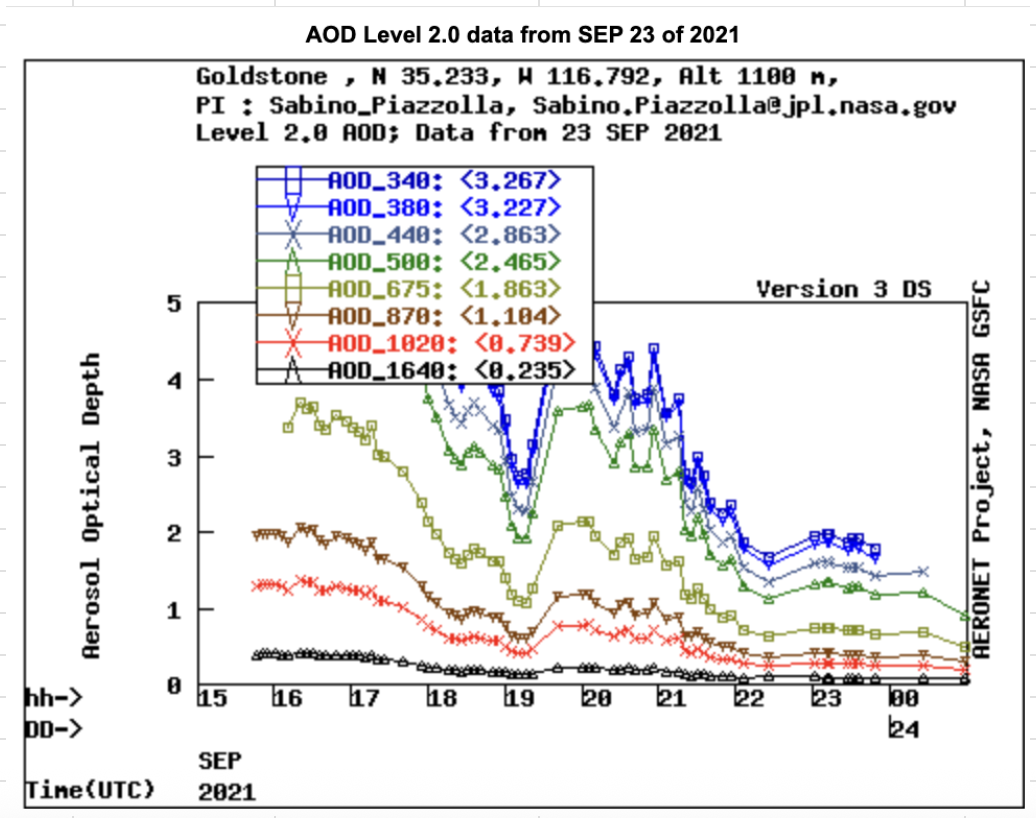

| Hour (UTC) | Hourly Average AOD (500 nm) | Hourly Average SZA (°) |
| :--- | :--- | :--- |
| 17.0 | 4.541 | 44.018 |
| 18.0 | 3.111 | 39.419 |
| 19.0 | 2.378 | 36.148 |
| 20.0 | 3.234 | 37.670 |
| 21.0 | 2.069 | 44.310 |
| 22.0 | 1.212 | 51.045 |
| 23.0 | 1.298 | 64.792 |
| 0.0 | 1.073 | 78.619 |
| **Average** | **2.364** | **37.670 (for mid day)** |

1. The primary source for the AOD anomaly at this station is likely due to an excess concentration of dust in the atmosphere. The Goldstone station, located in Barstow, California, is in the Mojave Desert, and September falls within the region's monsoon season.
   
2. The direct surface transmitance throughout the day is quite variable due to the rapid fluctuations in the AOD. On this day, the transmittance is lowest in the morning, when the AOD is around 4.5, then increases slightly before decreasing again at midday, and finally increases in the afternoon and evening as the AOD decreases. This trend is shown in the figure and table below.

   
3. With a constant $\tau$ value of the daily average (2.364), the direct transmitance throughout the day at the hourly average solar zenith angles is depicted by the blue line in the figure below. This trend is considerably less variable than the average measured hourly AOD and the SZA, plotted in black on the same graph. As a comparison to a homogeneous atmosphere, the histograms from the simple Monte Carlo model below depict the change in extinction path length as AOD is held constant and SZA varies.

   
4. The red line on the plot below shows the direct transmittance throughout the day for the average hourly AOD values with a constant SZA of 37.67. This trend is significantly more variable than that of the plot with constant AOD. This trend also deviates from the observed values beginning at 20:00 UTC, when the SZA increases, and the AOD decreases. As a comparison to a homogeneous atmosphere, the histograms from the simple Monte Carlo model below depict the change in extinction path length as SZA is held constant and AOD varies.

   
5. The scenario with a constant SZA of 37.67 but variable AOD indicates that the variable AOD in this dust event is the main driver of the change in surface transmittance. Once the dust begins to clear, the AOD decreases, and the afternoon SZA increases, the deviation from the observed model becomes prevalent. With a large AOD, the constant SZA scenario aligns with the observed trend in surface transmitance, but at lower AOD values, the impact on transmittance is dominated by SZA over AOD. This implies that during a dust event, surface transmittance is more dependent on the increased AOD than on the changing SZA.

Hour (UTC)   | AOD (tau)  | SZA (deg)  | Theoretical T (%) 
------------------------------------------------------------
17.0         | 4.541      | 44.018     | 0.1810            %
18.0         | 3.111      | 39.419     | 1.7827            %
19.0         | 2.378      | 36.148     | 5.2607            %
20.0         | 3.234      | 37.670     | 1.6812            %
21.0         | 2.069      | 44.310     | 5.5499            %
22.0         | 1.212      | 51.045     | 14.5474           %
23.0         | 1.298      | 64.792     | 4.7472            %
0.0          | 1.073      | 78.619     | 0.4350            %


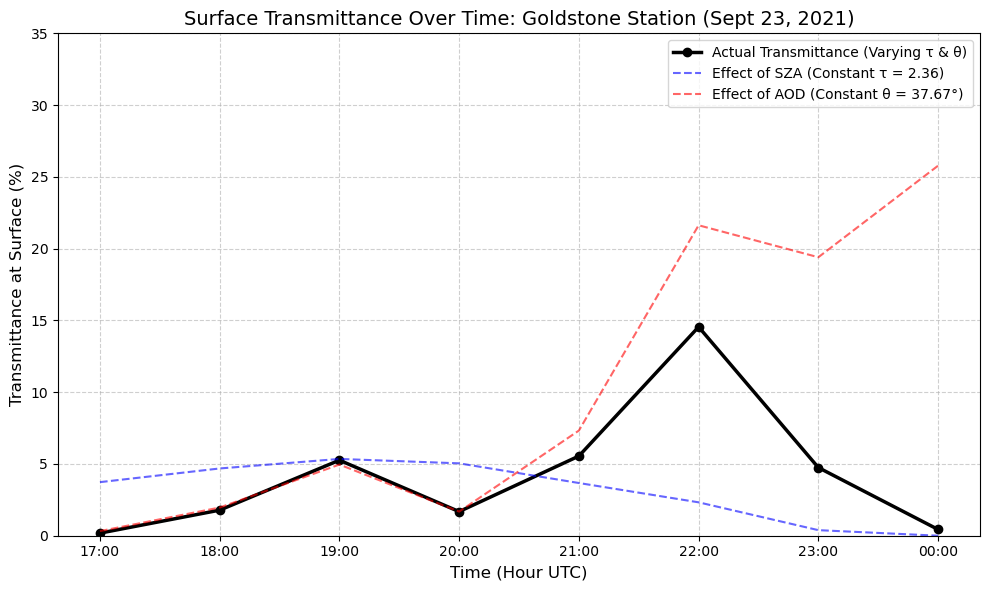

In [25]:
import numpy as np

# --- Average Hourly Data From Goldstone Station ---
hours = [17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 0.0]
aods  = [4.541, 3.111, 2.378, 3.234, 2.069, 1.212, 1.298, 1.073]
szas  = [44.018, 39.419, 36.148, 37.670, 44.310, 51.045, 64.792, 78.619]

print(f"{'Hour (UTC)':<12} | {'AOD (tau)':<10} | {'SZA (deg)':<10} | {'Theoretical T (%)':<18}")
print("-" * 60)


for h, tau, sza in zip(hours, aods, szas):
    # 1. Theoretical Calculation
    mu = np.cos(np.radians(sza))
    # Transmittance = exp(-tau / cos(theta))
    theory_t = np.exp(-tau / mu) * 100
    
    print(f"{h:<12.1f} | {tau:<10.3f} | {sza:<10.3f} | {theory_t:<18.4f}%")
    

import matplotlib.pyplot as plt

# Data from the table
hours = np.array([17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0]) # 0.0 treated as 24.0 for sequence
aods  = np.array([4.541, 3.111, 2.378, 3.234, 2.069, 1.212, 1.298, 1.073])
szas  = np.array([44.018, 39.419, 36.148, 37.670, 44.310, 51.045, 64.792, 78.619])

# Real Transmittance
mu = np.cos(np.radians(szas))
transmittance = np.exp(-aods / mu) * 100

# Constant Tau scenario (daily mean AOD)
mean_aod = np.mean(aods)
trans_const_tau = np.exp(-mean_aod / mu) * 100

# Constant SZA scenario (mid-day SZA)
noon_sza = 37.670 
trans_const_sza = np.exp(-aods / np.cos(np.radians(noon_sza))) * 100

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(hours, transmittance, 'o-', color='black', linewidth=2.5, label='Actual Transmittance (Varying τ & θ)')
plt.plot(hours, trans_const_tau, '--', color='blue', alpha=0.6, label=f'Effect of SZA (Constant τ = {mean_aod:.2f})')
plt.plot(hours, trans_const_sza, '--', color='red', alpha=0.6, label=f'Effect of AOD (Constant θ = {noon_sza:.2f}°)')

plt.title('Surface Transmittance Over Time: Goldstone Station (Sept 23, 2021)', fontsize=14)
plt.xlabel('Time (Hour UTC)', fontsize=12)
plt.ylabel('Transmittance at Surface (%)', fontsize=12)
plt.xticks(hours, ['17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00', '00:00'])
plt.ylim(0, 35) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig('transmittance_no_arrow.png', dpi=300)
plt.show()

--- STARTING SZA VARIATION ---

RUNNING: SZA=0, Tau=2.4647
Surface Hits: 850 (8.50%) | Theory: 8.50%


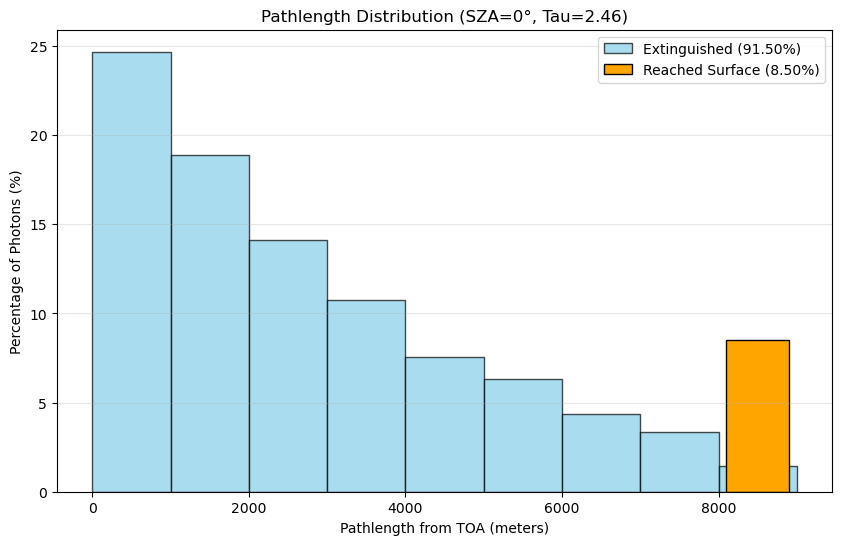


RUNNING: SZA=30, Tau=2.4647
Surface Hits: 580 (5.80%) | Theory: 5.81%


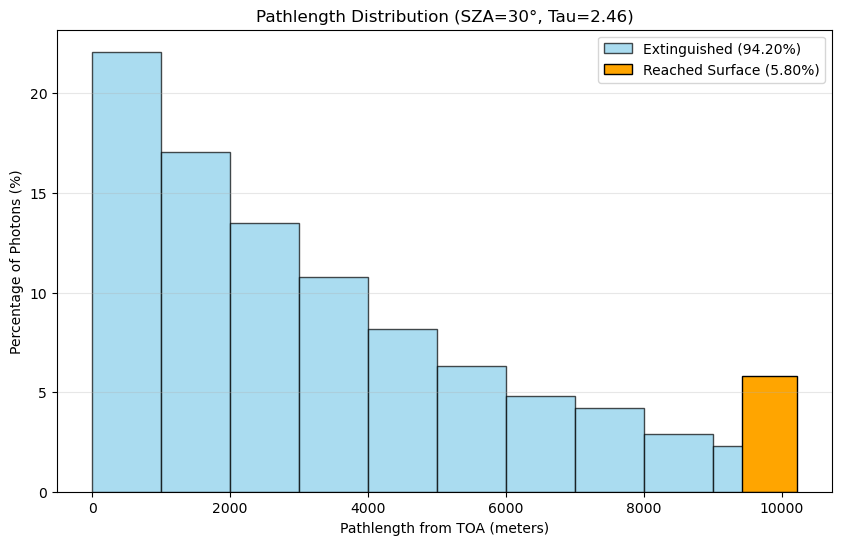


RUNNING: SZA=60, Tau=2.4647
Surface Hits: 78 (0.78%) | Theory: 0.72%


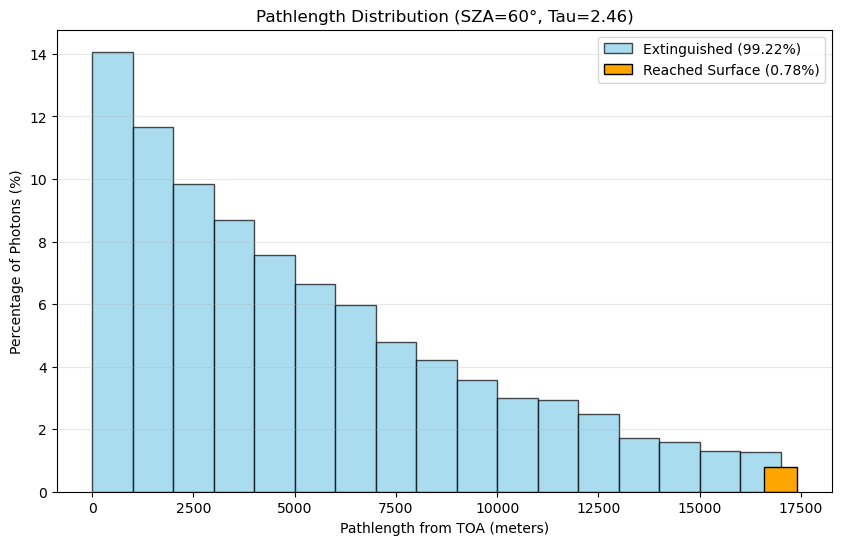


RUNNING: SZA=80, Tau=2.4647
Surface Hits: 0 (0.00%) | Theory: 0.00%


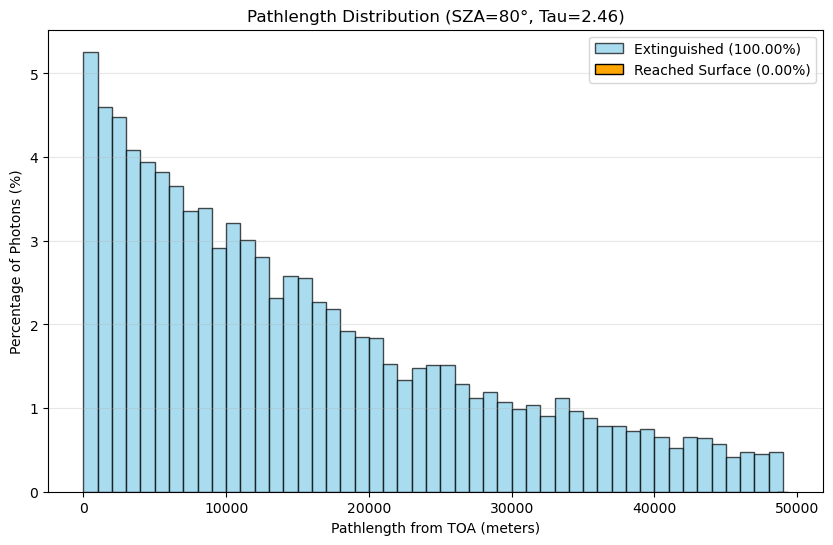


--- STARTING TAU VARIATION ---

RUNNING: SZA=37.6, Tau=0.5000
Surface Hits: 5,281 (52.81%) | Theory: 53.20%


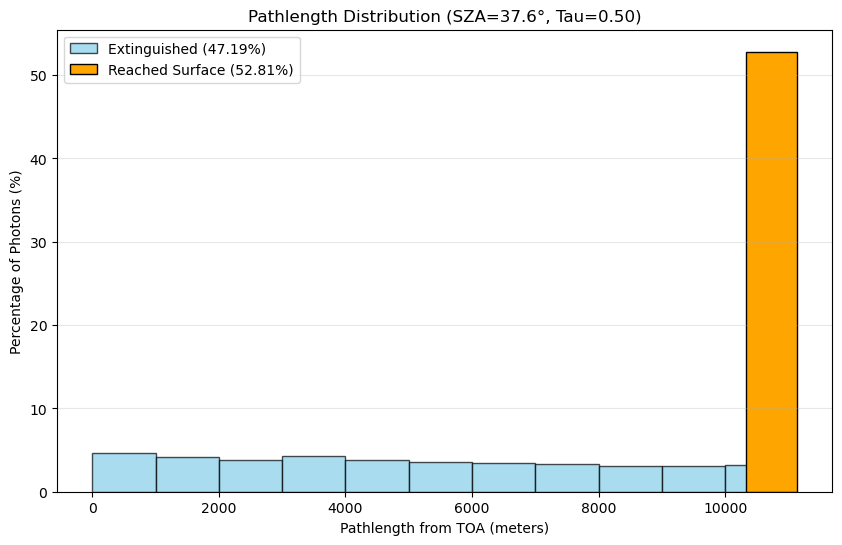


RUNNING: SZA=37.6, Tau=1.0000
Surface Hits: 2,806 (28.06%) | Theory: 28.30%


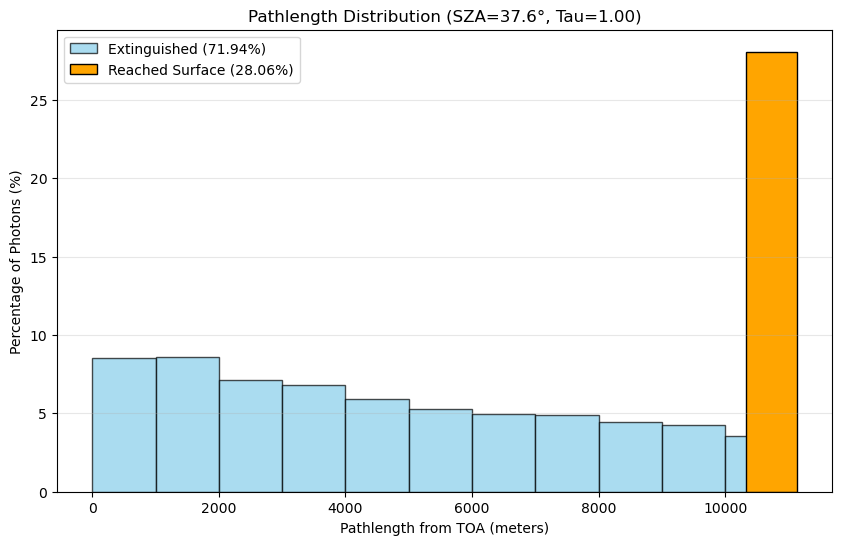


RUNNING: SZA=37.6, Tau=2.5000
Surface Hits: 371 (3.71%) | Theory: 4.26%


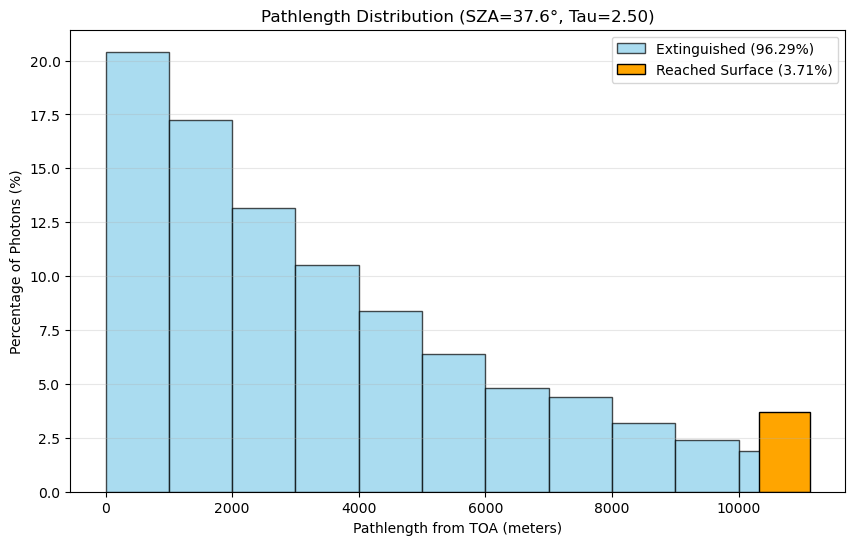


RUNNING: SZA=37.6, Tau=5.0000
Surface Hits: 21 (0.21%) | Theory: 0.18%


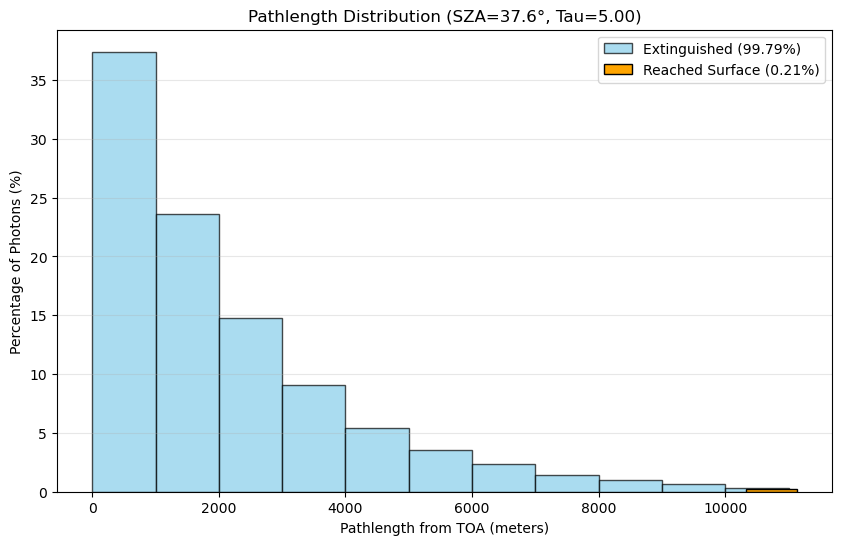

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parameters ---
N_INCIDENT = 10000 
Z_ATM = 8500 
BIN_SIZE = 1000 

def run_simulation(tau_star, sza_deg):
    # 1. Setup Slant Geometry
    mu = np.cos(np.radians(sza_deg))
    mu = max(mu, 0.0001) 
    
    tau_slant_path = tau_star / mu 
    L_total = Z_ATM / mu 

    surf_paths = [] 
    ext_paths = []

    # 2. Monte Carlo Loop
    for _ in range(N_INCIDENT):
        zeta = np.random.rand()
        tau_sampled = -np.log(1 - zeta)
        
        if tau_sampled >= tau_slant_path:
            surf_paths.append(L_total)
        else:
            # L = (Zatm / mu) * (tau_sampled / tau_star)
            L_ext = (Z_ATM / mu) * (tau_sampled / tau_star)
            ext_paths.append(L_ext)

    # 3. Statistics
    surf_count = len(surf_paths)
    ext_count = len(ext_paths)
    ext_pct = (ext_count / N_INCIDENT) * 100
    surf_pct = (surf_count / N_INCIDENT) * 100
    theory_pct = np.exp(-tau_slant_path) * 100
    
    print(f"\nRUNNING: SZA={sza_deg}, Tau={tau_star:.4f}")
    print(f"Surface Hits: {surf_count:,} ({surf_pct:.2f}%) | Theory: {theory_pct:.2f}%")

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, L_total + BIN_SIZE, BIN_SIZE)
    
    plt.hist(ext_paths, bins=bins, weights=np.ones_like(ext_paths)*100/N_INCIDENT, 
             color='skyblue', edgecolor='black', alpha=0.7, label=f'Extinguished ({ext_pct:.2f}%)')
    
    plt.bar(L_total, surf_pct, width=BIN_SIZE*0.8, color='orange', 
            edgecolor='black', label=f'Reached Surface ({surf_pct:.2f}%)')

    plt.title(f'Pathlength Distribution (SZA={sza_deg}°, Tau={tau_star:.2f})')
    plt.xlabel('Pathlength from TOA (meters)')
    plt.ylabel('Percentage of Photons (%)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 5. Save to Folder
    folder = "figures"
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    file_name = f"mcrt_sza{sza_deg}_tau{tau_star:.2f}.png"
    plt.savefig(os.path.join(folder, file_name), dpi=300)
    plt.show()

# --- EXECUTION SECTION ---

# Scenario A: Keep Tau constant, vary SZA
constant_tau = 2.4647
sza_list = [0, 30, 60, 80]

print("--- STARTING SZA VARIATION ---")
for sza in sza_list:
    run_simulation(tau_star=constant_tau, sza_deg=sza)

# Scenario B: Keep SZA constant, vary Tau
constant_sza = 37.6
tau_list = [0.5, 1.0, 2.5, 5.0]

print("\n--- STARTING TAU VARIATION ---")
for t in tau_list:
    run_simulation(tau_star=t, sza_deg=constant_sza)

# Part V: Student Investigation

Question: At what solar zenith angle does the increased photon pathlength bring the surface transmittance to 0%? 
Hypothesis: The exact solar zenith angle where this cuttoff occurs will be heavily influenced by $\tau^*$, but aligning with the previously measured AERONET average AOD of 2.46 during my time of interest, I expect the cutoff to be around 70-75%. 

Experiment (simulation below): 

1) Simulate and calculate the pathlength distribution of the photons that are extinguished and reach the surface for SZA of 0 (control), 55, 65, and 70.
2) Once the 0% threshold is reached, input SZA values in between the initial parameters to find the exact cutoff point
3) Calculate the theoretical surface transmission at this point to confirm the model's accuracy and precision
   The calculated therotical surface transmission at 76˚ for an AOD of 2.4647 was 0.003%
5) Conclusion: The Monte Carlo model's cutoff point for surface transmittance is at a solar zenith angle of 76 +/- 1, based on the calculated %theoretical surface transmission at 76˚ being 0.003% the model aligns with the theoretical value considering the value falls below the model resolution of 0.01%
    
   Statistically, there is no definite cutoff point until 90˚, but as the angle increases, it becomes significantly less probable. The lowest calculated probability of surface transmission that I could generate was 2.18271E-120 for a solar zenith angle of 89.5.  

--- STARTING SZA VARIATION ---

RUNNING: SZA=0, Tau=2.4647
Surface Hits: 856 (8.56%) | Theory: 8.50%


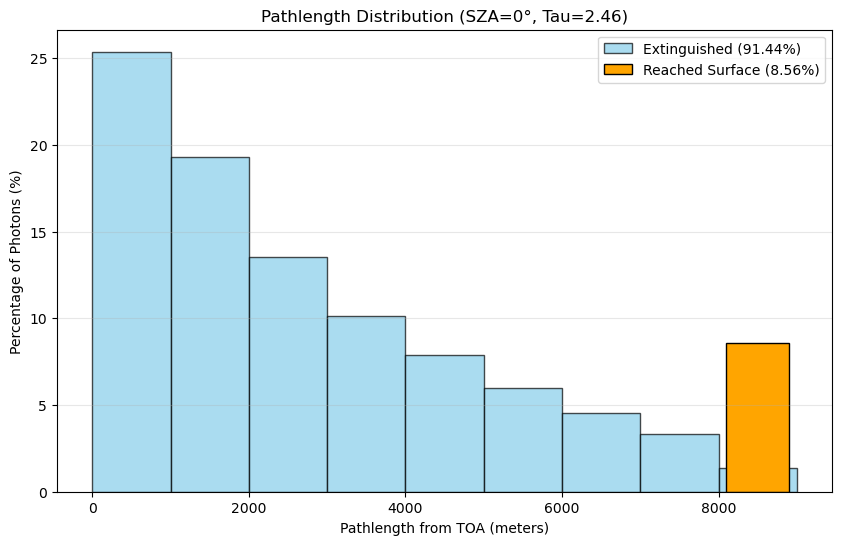


RUNNING: SZA=55, Tau=2.4647
Surface Hits: 127 (1.27%) | Theory: 1.36%


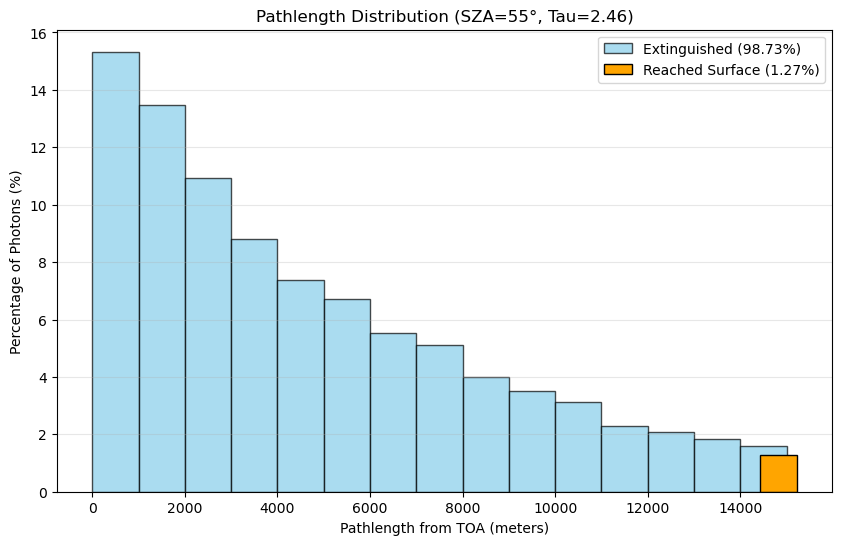


RUNNING: SZA=65, Tau=2.4647
Surface Hits: 37 (0.37%) | Theory: 0.29%


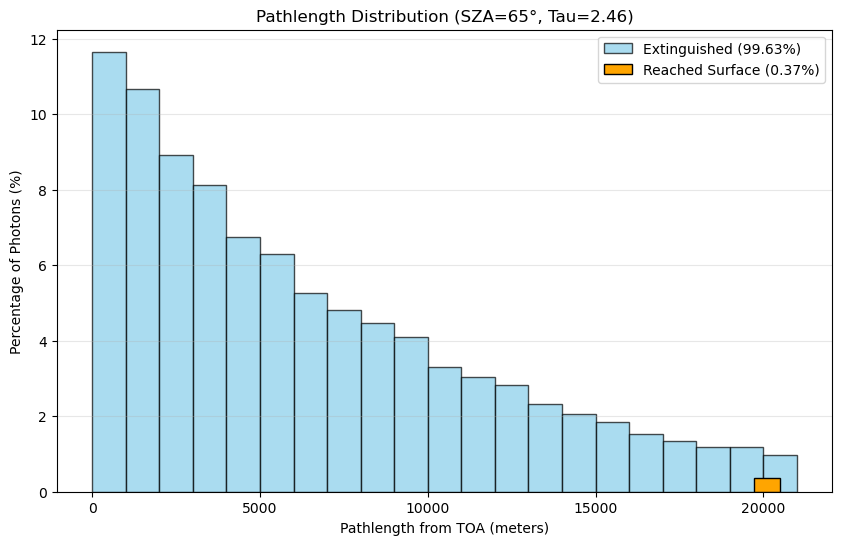


RUNNING: SZA=70, Tau=2.4647
Surface Hits: 5 (0.05%) | Theory: 0.07%


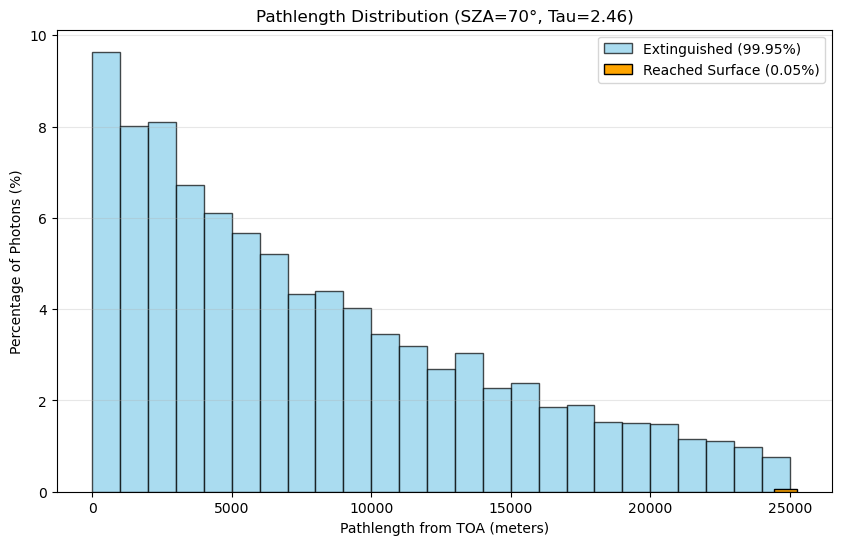


RUNNING: SZA=71, Tau=2.4647
Surface Hits: 3 (0.03%) | Theory: 0.05%


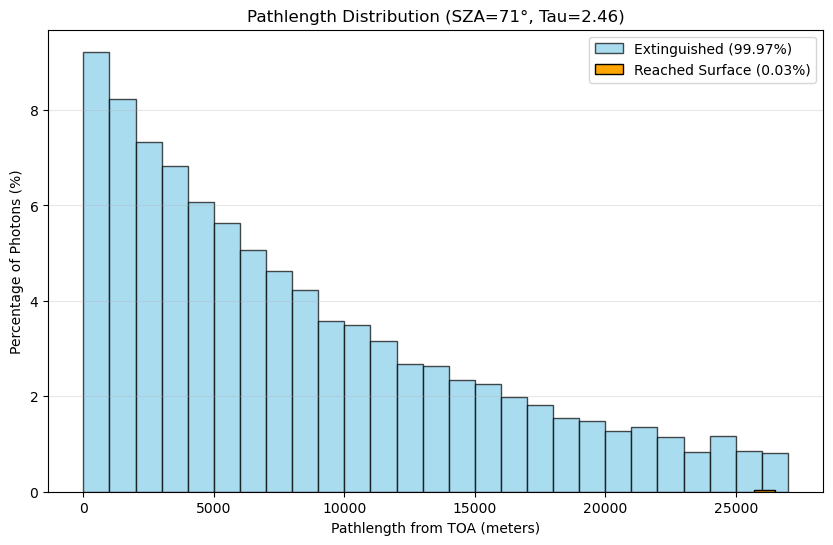


RUNNING: SZA=72, Tau=2.4647
Surface Hits: 4 (0.04%) | Theory: 0.03%


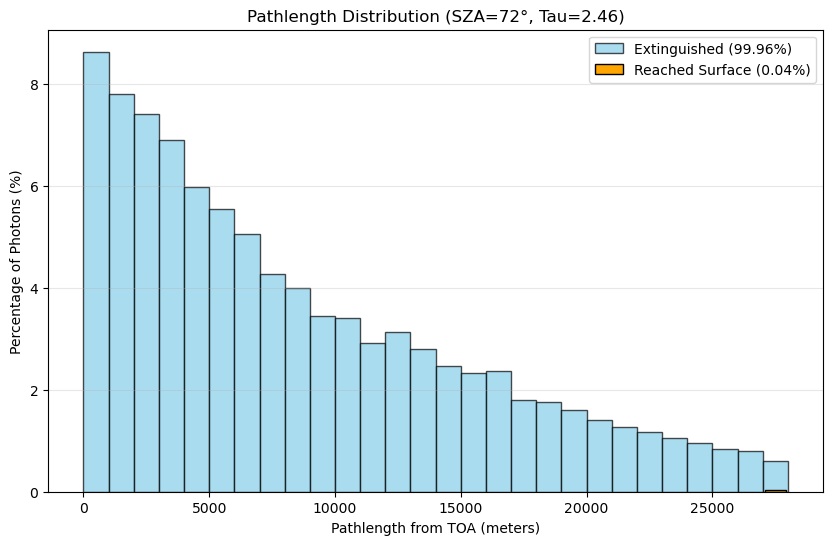


RUNNING: SZA=73, Tau=2.4647
Surface Hits: 1 (0.01%) | Theory: 0.02%


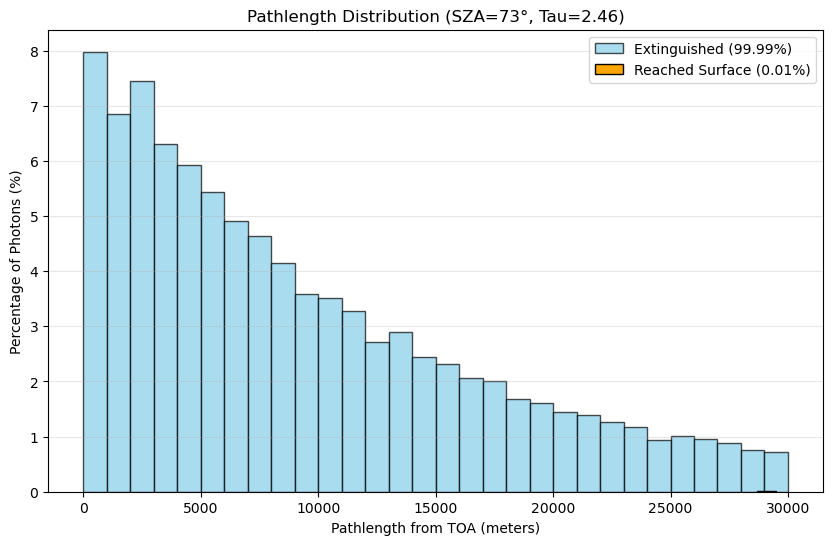


RUNNING: SZA=74, Tau=2.4647
Surface Hits: 3 (0.03%) | Theory: 0.01%


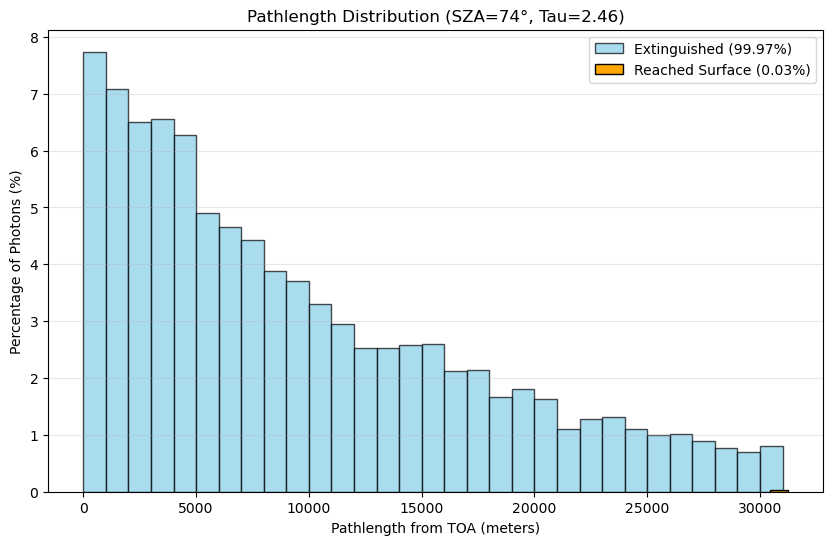


RUNNING: SZA=75, Tau=2.4647
Surface Hits: 0 (0.00%) | Theory: 0.01%


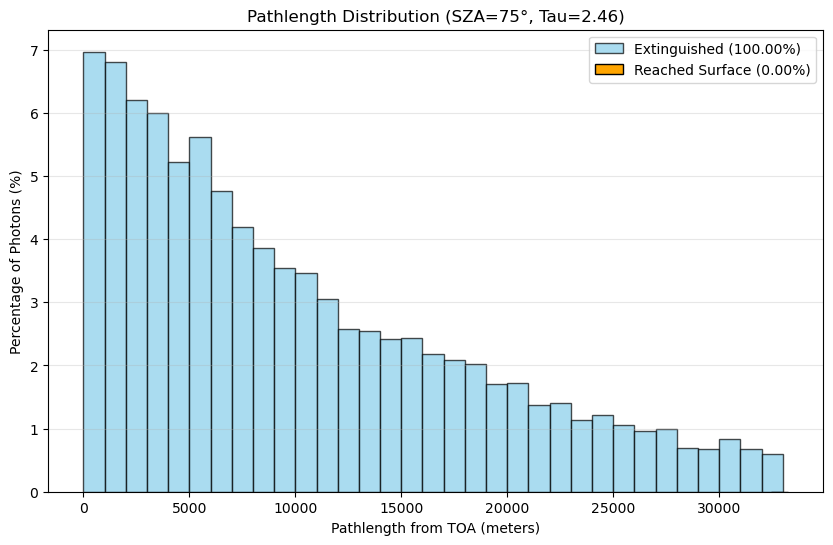


RUNNING: SZA=76, Tau=2.4647
Surface Hits: 0 (0.00%) | Theory: 0.00%


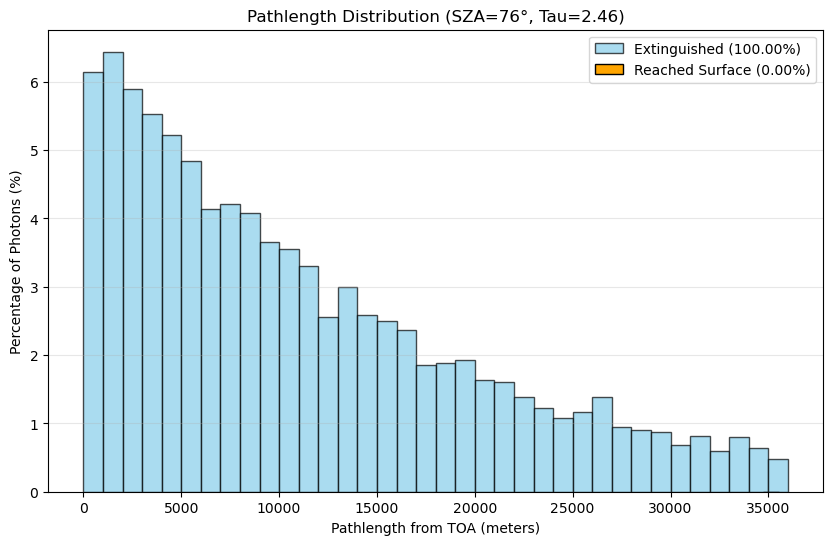

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parameters ---
N_INCIDENT = 10000 
Z_ATM = 8500 
BIN_SIZE = 1000 

def run_simulation(tau_star, sza_deg):
    # 1. Setup Slant Pathlength
    mu = np.cos(np.radians(sza_deg))
    mu = max(mu, 0.0001) 
    
    tau_slant_path = tau_star / mu 
    L_total = Z_ATM / mu 

    surf_paths = [] 
    ext_paths = []

    # 2. Monte Carlo Loop
    for _ in range(N_INCIDENT):
        zeta = np.random.rand()
        tau_sampled = -np.log(1 - zeta)
        
        if tau_sampled >= tau_slant_path:
            surf_paths.append(L_total)
        else:
            # L = (Zatm / mu) * (tau_sampled / tau_star)
            L_ext = (Z_ATM / mu) * (tau_sampled / tau_star)
            ext_paths.append(L_ext)

    # 3. Statistics
    surf_count = len(surf_paths)
    ext_count = len(ext_paths)
    ext_pct = (ext_count / N_INCIDENT) * 100
    surf_pct = (surf_count / N_INCIDENT) * 100
    theory_pct = np.exp(-tau_slant_path) * 100
    
    print(f"\nRUNNING: SZA={sza_deg}, Tau={tau_star:.4f}")
    print(f"Surface Hits: {surf_count:,} ({surf_pct:.2f}%) | Theory: {theory_pct:.2f}%")

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, L_total + BIN_SIZE, BIN_SIZE)
    
    plt.hist(ext_paths, bins=bins, weights=np.ones_like(ext_paths)*100/N_INCIDENT, 
             color='skyblue', edgecolor='black', alpha=0.7, label=f'Extinguished ({ext_pct:.2f}%)')
    
    plt.bar(L_total, surf_pct, width=BIN_SIZE*0.8, color='orange', 
            edgecolor='black', label=f'Reached Surface ({surf_pct:.2f}%)')

    plt.title(f'Pathlength Distribution (SZA={sza_deg}°, Tau={tau_star:.2f})')
    plt.xlabel('Pathlength from TOA (meters)')
    plt.ylabel('Percentage of Photons (%)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 5. Save to Folder
    folder = "figures"
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    
    file_name = f"mcrt_sza{sza_deg}_tau{tau_star:.2f}.png"
    plt.savefig(os.path.join(folder, file_name), dpi=300)
    plt.show()

# --- EXECUTION SECTION ---

# Scenario A: Keep Tau constant, vary SZA
constant_tau = 2.4647
sza_list = [0, 55, 65, 70, 71, 72, 73, 74, 75, 76]

print("--- STARTING SZA VARIATION ---")
for sza in sza_list:
    run_simulation(tau_star=constant_tau, sza_deg=sza)

# AI Usage

## Tool used: Google Gemini

How it was used: wrote all initial Python code. The prompt was to incorporate the given probability functions into a parallel plane model and, according to Beer's law, determine extinction events and photon transmittance to the surface in an absorbing atmosphere as a function of changing solar zenith angle and total optical depth. I specified that the atmosphere would have a depth of 8.5 km and be evenly mixed (homogenous). 

What I changed: I refined the code generated by Gemini to complete my objectives and generate representative figures. I verified the code's scientific merit and identified and fixed a formula error.  